In [ ]:
from statsbombpy import sb
competitions = sb.competitions()
import pandas as pd



matches = sb.matches(competition_id= 55, season_id=282)
print(matches.shape)
matches.head()
print(matches.columns.tolist())

spain_matches = matches[(matches['home_team'] == 'Spain') | (matches['away_team'] == 'Spain')]
print(spain_matches[['match_id', 'match_date', 'home_team', 'away_team', 'home_score', 'away_score', 'competition_stage']])

game1 = sb.events(match_id= 3930160)
print(game1["type"].value_counts())

lineup= game1[ (game1['type'] == 'Starting XI')]
print (lineup)
print(lineup.columns.tolist())

print(lineup['tactics'].iloc[0])
players_list = lineup['tactics'].iloc[0]['lineup']

spain_lineup = []

for p in players_list:
    spain_lineup.append({
    "player": p['player']['name'],
    "position": p['position']["name"],
    "jersey_number": p['jersey_number']
    })

print(spain_lineup)

print(pd.DataFrame(spain_lineup))









C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


(51, 22)
['match_id', 'match_date', 'kick_off', 'competition', 'season', 'home_team', 'away_team', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_stage', 'stadium', 'referee', 'home_managers', 'away_managers', 'data_version', 'shot_fidelity_version', 'xy_fidelity_version']
    match_id  match_date home_team away_team  home_score  away_score  \
1    3943043  2024-07-14     Spain   England           2           1   
2    3942752  2024-07-09     Spain    France           2           1   
8    3942226  2024-07-05     Spain   Germany           2           1   
15   3941018  2024-06-30     Spain   Georgia           4           1   
18   3930179  2024-06-24   Albania     Spain           0           1   
23   3930172  2024-06-20     Spain     Italy           1           0   
48   3930160  2024-06-15     Spain   Croatia           3           0   

   competition_stage  
1              Final  
2        Semi-finals  


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


type
Pass                 1048
Ball Receipt*        1016
Carry                 844
Pressure              430
Ball Recovery          75
Duel                   63
Block                  47
Goal Keeper            36
Foul Committed         29
Shot                   27
Foul Won               27
Dribble                22
Dispossessed           22
Miscontrol             18
Clearance              15
Dribbled Past          15
Interception           14
Substitution            9
Injury Stoppage         8
50/50                   8
Referee Ball-Drop       6
Half End                4
Half Start              4
Tactical Shift          3
Starting XI             2
Player Off              1
Player On               1
Shield                  1
Offside                 1
Name: count, dtype: int64
  50_50 ball_receipt_outcome ball_recovery_recovery_failure block_deflection  \
0   NaN                  NaN                            NaN              NaN   
1   NaN                  NaN                           

In [4]:
xG= game1[ (game1['type'] == 'Shot')]


spain_shots = xG[(xG['team'] == 'Spain')]

spain_shots[['player', 'team', 'minute', 'location', 'shot_outcome', 'shot_body_part', 'shot_technique', 'shot_type', 'shot_statsbomb_xg']]


,player,team,minute,location,shot_outcome,shot_body_part,shot_technique,shot_type,shot_statsbomb_xg
3727,Álvaro Borja Morata Martín,Spain,6,"[98.8, 47.5]",Saved,Left Foot,Half Volley,Open Play,0.053676
3728,Lamine Yamal Nasraoui Ebana,Spain,14,"[106.5, 49.9]",Saved Off Target,Left Foot,Normal,Open Play,0.048078
3730,Álvaro Borja Morata Martín,Spain,28,"[104.1, 39.9]",Goal,Left Foot,Normal,Open Play,0.425340
3732,Fabián Ruiz Peña,Spain,31,"[103.9, 38.7]",Goal,Left Foot,Normal,Open Play,0.056130
3735,Robin Aime Robert Le Normand,Spain,35,"[114.2, 35.6]",Blocked,Head,Normal,Open Play,0.108392
3739,Daniel Carvajal Ramos,Spain,46,"[112.7, 42.4]",Goal,Right Foot,Volley,Open Play,0.301003
3741,Lamine Yamal Nasraoui Ebana,Spain,51,"[108.6, 48.3]",Saved,Left Foot,Normal,Open Play,0.281681
3742,Álvaro Borja Morata Martín,Spain,53,"[117.4, 34.5]",Wayward,Other,Normal,Open Play,0.210361
3747,Lamine Yamal Nasraoui Ebana,Spain,57,"[91.3, 45.4]",Blocked,Left Foot,Normal,Free Kick,0.042339
3748,Daniel Olmo Carvajal,Spain,73,"[93.9, 39.0]",Blocked,Right Foot,Normal,Open Play,0.027441


In [5]:
expected_goals = 'shot_statsbomb_xg'
x = sum(spain_shots[expected_goals])
print(f"Total expected goals for Spain: {x}")

Total expected goals for Spain: 1.567182589


In [6]:
checkgoal = spain_shots[spain_shots['shot_outcome'] == 'Goal']
print(checkgoal[['player', 'shot_statsbomb_xg', "shot_outcome"]])

                          player  shot_statsbomb_xg shot_outcome
3730  Álvaro Borja Morata Martín           0.425340         Goal
3732            Fabián Ruiz Peña           0.056130         Goal
3739       Daniel Carvajal Ramos           0.301003         Goal


In [7]:
xG= game1[ (game1['type'] == 'Shot')]


croatia_shots = xG[(xG['team'] == 'Croatia')]

croatia_shots[['player', 'team', 'minute', 'location', 'shot_outcome', 'shot_body_part', 'shot_technique', 'shot_type', 'shot_statsbomb_xg']]


,player,team,minute,location,shot_outcome,shot_body_part,shot_technique,shot_type,shot_statsbomb_xg
3729,Ante Budimir,Croatia,21,"[107.7, 39.3]",Off T,Head,Normal,Open Play,0.048898
3731,Mateo Kovačić,Croatia,29,"[102.8, 38.7]",Saved,Left Foot,Normal,Open Play,0.063781
3733,Marcelo Brozović,Croatia,32,"[101.8, 40.2]",Saved,Right Foot,Normal,Open Play,0.077752
3734,Lovro Majer,Croatia,32,"[116.5, 50.1]",Off T,Right Foot,Normal,Open Play,0.106451
3736,Joško Gvardiol,Croatia,40,"[114.0, 27.5]",Off T,Left Foot,Half Volley,Open Play,0.050448
3737,Andrej Kramarić,Croatia,44,"[86.3, 47.4]",Off T,Right Foot,Normal,Open Play,0.013198
3738,Mateo Kovačić,Croatia,45,"[91.0, 30.4]",Off T,Right Foot,Normal,Open Play,0.019094
3740,Joško Gvardiol,Croatia,50,"[101.2, 24.0]",Blocked,Left Foot,Half Volley,Open Play,0.018449
3743,Josip Stanišić,Croatia,54,"[111.9, 47.8]",Blocked,Right Foot,Normal,Open Play,0.222950
3744,Ante Budimir,Croatia,54,"[117.0, 37.0]",Blocked,Head,Normal,Open Play,0.206007


In [8]:
expected_goals = 'shot_statsbomb_xg'
x = sum(croatia_shots[expected_goals])
print(f"Total expected goals for Croatia: {x}")

Total expected goals for Croatia: 2.48209888


In [9]:
checkgoal = croatia_shots[croatia_shots['shot_outcome'] == 'Goal']
print(checkgoal[['player', 'shot_statsbomb_xg', "shot_outcome"]])

Empty DataFrame
Columns: [player, shot_statsbomb_xg, shot_outcome]
Index: []


In [10]:
print(game1['possession_team'].value_counts())

possession_team
Croatia    2015
Spain      1781
Name: count, dtype: int64


In [11]:
counts = game1['possession_team'].value_counts()
print(counts['Spain'])
print(counts['Croatia'])

total_possesion = counts['Croatia'] + counts['Spain']
spain_possesion = counts['Spain'] / total_possesion * 100
croatia_possesion = counts['Croatia'] / total_possesion * 100
print (f"Spain possesion is : {spain_possesion:.2f}%")
print (f"Croatia Possesion: {croatia_possesion:.2f}%")

1781
2015
Spain possesion is : 46.92%
Croatia Possesion: 53.08%


In [12]:
shots = game1[game1['type'] == 'Shot']
spain_shots = shots[shots['team'] == 'Spain']
print(spain_shots['location'])

croatia_shots = shots[shots['team'] == 'Croatia']
print(croatia_shots['location'])

3727     [98.8, 47.5]
3728    [106.5, 49.9]
3730    [104.1, 39.9]
3732    [103.9, 38.7]
3735    [114.2, 35.6]
3739    [112.7, 42.4]
3741    [108.6, 48.3]
3742    [117.4, 34.5]
3747     [91.3, 45.4]
3748     [93.9, 39.0]
3752    [109.6, 57.8]
Name: location, dtype: object
3729    [107.7, 39.3]
3731    [102.8, 38.7]
3733    [101.8, 40.2]
3734    [116.5, 50.1]
3736    [114.0, 27.5]
3737     [86.3, 47.4]
3738     [91.0, 30.4]
3740    [101.2, 24.0]
3743    [111.9, 47.8]
3744    [117.0, 37.0]
3745    [118.4, 40.0]
3746    [115.1, 34.4]
3749    [108.0, 40.0]
3750    [101.4, 28.7]
3751     [87.3, 24.7]
3753    [107.8, 27.5]
Name: location, dtype: object


In [13]:
spain_shots = shots[shots['team'] == 'Spain'].copy()
spain_shots['x'] = spain_shots['location'].apply(lambda loc: loc[0])
spain_shots['y'] = spain_shots['location'].apply(lambda loc: loc[1])



In [14]:
lineup_df = pd.DataFrame(spain_lineup)
spain_shots = shots[shots['team'] == 'Spain'].copy()
spain_shots['x'] = spain_shots['location'].apply(lambda loc: loc[0])
spain_shots['y'] = spain_shots['location'].apply(lambda loc: loc[1])
spain_shots = spain_shots.merge(lineup_df[['player', 'jersey_number']], on='player', how='left')
spain_shots.loc[spain_shots['player'] == 'Ferrán Torres García', 'jersey_number'] = 11
spain_shots.loc[spain_shots['player'] == 'Daniel Olmo Carvajal', 'jersey_number'] = 8
print(spain_shots[['player', 'jersey_number']])


                          player  jersey_number
0     Álvaro Borja Morata Martín            7.0
1    Lamine Yamal Nasraoui Ebana           19.0
2     Álvaro Borja Morata Martín            7.0
3               Fabián Ruiz Peña            8.0
4   Robin Aime Robert Le Normand            3.0
5          Daniel Carvajal Ramos            2.0
6    Lamine Yamal Nasraoui Ebana           19.0
7     Álvaro Borja Morata Martín            7.0
8    Lamine Yamal Nasraoui Ebana           19.0
9           Daniel Olmo Carvajal            8.0
10          Ferrán Torres García           11.0


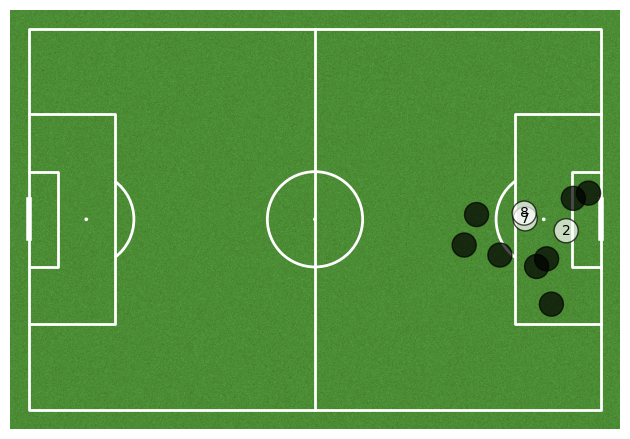

In [15]:
import random 
from mplsoccer import Pitch

pitch = Pitch(pitch_color='grass', line_color='white')
fig, ax = pitch.draw()

colors = []
for outcome in spain_shots['shot_outcome']:
    if outcome == 'Goal':
        colors.append('white')
        
            
    else:
        colors.append('black')


for idx in spain_shots.iterrows():
    if idx[1]['shot_outcome'] == 'Goal':
        pitch.annotate(str(int(idx[1]['jersey_number'])), xy=(idx[1]['x'], idx[1]['y']), ax=ax, ha='center', va='center')


pitch.scatter(spain_shots['x'], spain_shots['y'], ax=ax, color=colors, edgecolors='black', s=300, label='Spain Shots', alpha=0.7)

In [16]:
croatia_shots = shots[shots['team'] == 'Croatia'].copy()
croatia_shots['x'] = croatia_shots['location'].apply(lambda loc: loc[0])
croatia_shots['y'] = croatia_shots['location'].apply(lambda loc: loc[1])

In [17]:
lineup = game1[game1['type'] == 'Starting XI']
croatia_starting = lineup[lineup['team'] == 'Croatia'].iloc[0]

croatia_lineup = []
for p in croatia_starting['tactics']['lineup']:
    croatia_lineup.append({
        "player": p['player']['name'],
        "position": p['position']['name'],
        "jersey_number": p['jersey_number']
    })

lineup_df = pd.DataFrame(croatia_lineup)

croatia_shots = shots[shots['team'] == 'Croatia'].copy()
croatia_shots['x'] = croatia_shots['location'].apply(lambda loc: loc[0])
croatia_shots['y'] = croatia_shots['location'].apply(lambda loc: loc[1])
croatia_shots = croatia_shots.merge(lineup_df[['player', 'jersey_number']], on='player', how='left')
croatia_shots_shots = shots[shots['team'] == 'Croatia'].copy()
croatia_shots_shots_shots = shots[shots['team'] == 'Croatia'].copy()
croatia_shots_shots_shots['x'] = croatia_shots_shots_shots['location'].apply(lambda loc: loc[0])
croatia_shots_shots_shots['y'] = croatia_shots_shots_shots['location'].apply(lambda loc: loc[1])
croatia_shots_shots_shots = croatia_shots_shots_shots.merge(lineup_df[['player', 'jersey_number']], on='player', how='left')
croatia_shots.loc[croatia_shots['player'] == 'Ivan Perišić', 'jersey_number'] = 4

print(croatia_shots[['player', 'jersey_number']])


              player  jersey_number
0       Ante Budimir           16.0
1      Mateo Kovačić            8.0
2   Marcelo Brozović           11.0
3        Lovro Majer            7.0
4     Joško Gvardiol            4.0
5    Andrej Kramarić            9.0
6      Mateo Kovačić            8.0
7     Joško Gvardiol            4.0
8     Josip Stanišić            2.0
9       Ante Budimir           16.0
10   Andrej Kramarić            9.0
11     Mateo Kovačić            8.0
12    Bruno Petković            NaN
13      Ivan Perišić            4.0
14      Ivan Perišić            4.0
15      Ivan Perišić            4.0


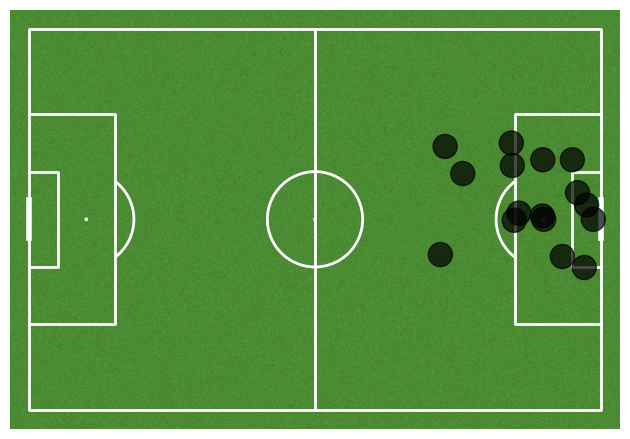

In [18]:
import random 
from mplsoccer import Pitch

pitch = Pitch(pitch_color='grass', line_color='white')
fig, ax = pitch.draw()

colors = []
for outcome in croatia_shots['shot_outcome']:
    if outcome == 'Goal':
        colors.append('white')
        
            
    else:
        colors.append('black')

for idx in croatia_shots.iterrows():
    if idx[1]['shot_outcome'] == 'Goal':
        pitch.annotate(str(int(idx[1]['jersey_number'])), xy=(idx[1]['x'], idx[1]['y']), ax=ax, ha='center', va='center')

pitch.scatter(croatia_shots['x'], croatia_shots['y'], ax=ax, color=colors, edgecolors='black', s=300, label='Croatia Shots', alpha=0.7)

In [19]:
passing= game1[(game1['type'] == 'Pass') | (game1['type'] == 'Carry')]


spain_passing = passing[(passing['team'] == 'Spain')]

spain_passing[['player', 'team', 'minute', 'location', 'pass_recipient', 'pass_length', 'pass_angle', 'carry_end_location']]


,player,team,minute,location,pass_recipient,pass_length,pass_angle,carry_end_location
8,Daniel Carvajal Ramos,Spain,0,"[33.0, 80.0]",Álvaro Borja Morata Martín,17.670880,-0.608408,NaN
9,Álvaro Borja Morata Martín,Spain,0,"[47.5, 69.9]",Pedro González López,14.450605,-0.992390,NaN
13,José Ignacio Fernández Iglesias,Spain,0,"[27.2, 24.0]",Unai Simón Mendibil,19.946178,2.610631,NaN
14,Unai Simón Mendibil,Spain,0,"[9.7, 33.9]",Robin Aime Robert Le Normand,21.423819,1.463232,NaN
15,Robin Aime Robert Le Normand,Spain,0,"[18.1, 54.5]",José Ignacio Fernández Iglesias,33.340816,-1.450534,NaN
...,...,...,...,...,...,...,...,...
2900,Mikel Oyarzabal Ugarte,Spain,93,"[26.8, 22.6]",NaN,NaN,NaN,"[32.9, 13.3]"
2901,Daniel Olmo Carvajal,Spain,93,"[38.2, 4.1]",NaN,NaN,NaN,"[40.9, 4.7]"
2902,Mikel Oyarzabal Ugarte,Spain,93,"[84.6, 8.2]",NaN,NaN,NaN,"[82.8, 8.6]"
2908,Fabián Ruiz Peña,Spain,94,"[36.7, 56.3]",NaN,NaN,NaN,"[36.5, 54.4]"


In [20]:
spain_passing['x'] = spain_passing['location'].apply(lambda loc: loc[0])
spain_passing['y'] = spain_passing['location'].apply(lambda loc: loc[1])

lineup_df = pd.DataFrame(spain_lineup)
spain_passing = passing[passing['team'] == 'Spain'].copy()
spain_passing['x'] = spain_passing['location'].apply(lambda loc: loc[0])
spain_passing['y'] = spain_passing['location'].apply(lambda loc: loc[1])

spain_passing_h1 = spain_passing[spain_passing['period'] == 1]
spain_passing_h2 = spain_passing[spain_passing['period'] == 2]


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11032\3041448206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spain_passing['x'] = spain_passing['location'].apply(lambda loc: loc[0])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11032\3041448206.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spain_passing['y'] = spain_passing['location'].apply(lambda loc: loc[1])


Text(0.5, 1.0, 'Second Half')

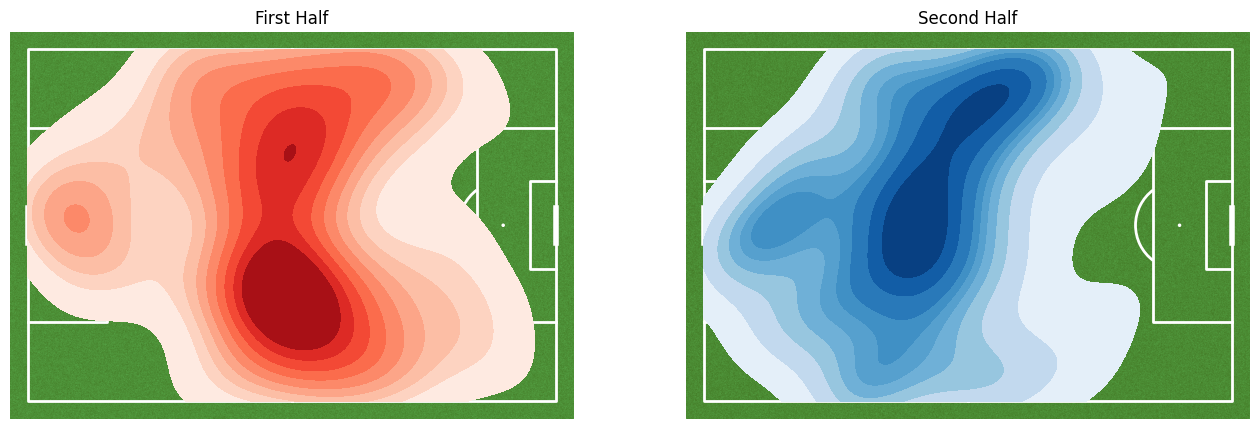

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


pitch.draw(ax=axes[0])
pitch.draw(ax=axes[1])


pitch = Pitch(pitch_color='grass', line_color='white')

pitch.kdeplot(spain_passing_h1["x"], spain_passing_h1["y"], ax=axes[0], fill=True, cmap='Reds')
pitch.kdeplot(spain_passing_h2["x"], spain_passing_h2["y"], ax=axes[1], fill=True, cmap='Blues')

axes[0].set_title('First Half')
axes[1].set_title('Second Half')

In [ ]:
# O(n) - loop through n matches to load events

all_events = []

for match_id in matches['match_id']:
    events = sb.events(match_id=match_id)
    all_events.append(events)

In [23]:
all_shots_df = pd.concat(all_events)
all_shots_df = all_shots_df[all_shots_df['type'] == 'Shot']
all_shots_df.shape



(1340, 114)

In [24]:
all_shots_df.columns.tolist()



['50_50',
 'bad_behaviour_card',
 'ball_receipt_outcome',
 'block_deflection',
 'block_save_block',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_right_foot',
 'counterpress',
 'dribble_outcome',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_committed_penalty',
 'foul_won_advantage',
 'foul_won_defensive',
 'foul_won_penalty',
 'goalkeeper_body_part',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_punched_out',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'injury_stoppage_in_chain',
 'interception_outcome',
 'location',
 'match_id',
 'minute',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_cut_back',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_assist',
 'pass_height',
 'pass_length',
 'pass_outcome',
 'pas

In [ ]:
all_shots_df.groupby(['match_id', 'team'])['shot_statsbomb_xg'].sum()


# O(n log n) - groupby sorts internally
match_xg = all_shots_df.groupby(['match_id', 'team'])['shot_statsbomb_xg'].sum().reset_index()
print(match_xg.shape)

(102, 3)


In [26]:
merged = match_xg.merge(matches, on='match_id')
merged

,match_id,team,shot_statsbomb_xg,match_date,kick_off,competition,season,home_team,away_team,home_score,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3930158,Germany,1.844634,2024-06-14,22:00:00.000,Europe - UEFA Euro,2024,Germany,Scotland,5,...,2024-07-04T08:13:19.028344,1,Group Stage,Allianz Arena,Clément Turpin,Julian Nagelsmann,Steve Clarke,1.1.0,2,2
1,3930158,Scotland,0.060526,2024-06-14,22:00:00.000,Europe - UEFA Euro,2024,Germany,Scotland,5,...,2024-07-04T08:13:19.028344,1,Group Stage,Allianz Arena,Clément Turpin,Julian Nagelsmann,Steve Clarke,1.1.0,2,2
2,3930159,Hungary,1.102846,2024-06-15,16:00:00.000,Europe - UEFA Euro,2024,Hungary,Switzerland,1,...,2024-07-10T13:35:35.263551,1,Group Stage,RheinEnergieStadion,Slavko Vinčić,Marco Rossi,Murat Yakin,1.1.0,2,2
3,3930159,Switzerland,2.095769,2024-06-15,16:00:00.000,Europe - UEFA Euro,2024,Hungary,Switzerland,1,...,2024-07-10T13:35:35.263551,1,Group Stage,RheinEnergieStadion,Slavko Vinčić,Marco Rossi,Murat Yakin,1.1.0,2,2
4,3930160,Croatia,2.482099,2024-06-15,19:00:00.000,Europe - UEFA Euro,2024,Spain,Croatia,3,...,2024-07-12T03:40:20.513429,1,Group Stage,Olympiastadion Berlin,Michael Oliver,Luis de la Fuente Castillo,Zlatko Dalić,1.1.0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,3942752,Spain,0.431201,2024-07-09,22:00:00.000,Europe - UEFA Euro,2024,Spain,France,2,...,2024-07-10T13:01:26.597509,6,Semi-finals,Allianz Arena,Slavko Vinčić,Luis de la Fuente Castillo,Didier Deschamps,1.1.0,2,2
98,3942819,England,1.253277,2024-07-10,22:00:00.000,Europe - UEFA Euro,2024,Netherlands,England,1,...,2024-07-15T07:57:36.684453,6,Semi-finals,Signal-Iduna-Park,Felix Zwayer,Ronald Koeman,Gareth Southgate,1.1.0,2,2
99,3942819,Netherlands,0.412172,2024-07-10,22:00:00.000,Europe - UEFA Euro,2024,Netherlands,England,1,...,2024-07-15T07:57:36.684453,6,Semi-finals,Signal-Iduna-Park,Felix Zwayer,Ronald Koeman,Gareth Southgate,1.1.0,2,2
100,3943043,England,0.726378,2024-07-14,22:00:00.000,Europe - UEFA Euro,2024,Spain,England,2,...,2024-07-15T15:52:24.778809,7,Final,Olympiastadion Berlin,François Letexier,Luis de la Fuente Castillo,Gareth Southgate,1.1.0,2,2


In [ ]:
# O(n) - iterrows loops through each row once
outcomes = []

for idx, row in merged.iterrows():
    if row["home_team"] == row["team"]:
        if row["home_score"] > row["away_score"]:
            outcomes.append("Win")
        elif row["home_score"] < row["away_score"]:
            outcomes.append("Loss")
        else:
            outcomes.append("Draw")
    else: 
        if row["away_score"] > row["home_score"]:
            outcomes.append("Win")
        elif row["away_score"] < row["home_score"]:
            outcomes.append("Loss")
        else:
            outcomes.append("Draw")
merged['outcome'] = outcomes
merged[["outcome", "home_team", "away_team","home_score", "away_score"]]

,outcome,home_team,away_team,home_score,away_score
0,Win,Germany,Scotland,5,1
1,Loss,Germany,Scotland,5,1
2,Loss,Hungary,Switzerland,1,3
3,Win,Hungary,Switzerland,1,3
4,Loss,Spain,Croatia,3,0
...,...,...,...,...,...
97,Win,Spain,France,2,1
98,Win,Netherlands,England,1,2
99,Loss,Netherlands,England,1,2
100,Loss,Spain,England,2,1


In [28]:
df = merged[["team", "outcome", "home_team", "away_team","shot_statsbomb_xg"]]

mapOutcome = {'Win': 2, 'Draw': 1, 'Loss': 0}
df['outcome'] = df['outcome'].map(mapOutcome)

print(df)

            team  outcome    home_team    away_team  shot_statsbomb_xg
0        Germany        2      Germany     Scotland           1.844634
1       Scotland        0      Germany     Scotland           0.060526
2        Hungary        0      Hungary  Switzerland           1.102846
3    Switzerland        2      Hungary  Switzerland           2.095769
4        Croatia        0        Spain      Croatia           2.482099
..           ...      ...          ...          ...                ...
97         Spain        2        Spain       France           0.431201
98       England        2  Netherlands      England           1.253277
99   Netherlands        0  Netherlands      England           0.412172
100      England        0        Spain      England           0.726378
101        Spain        2        Spain      England           1.791713

[102 rows x 5 columns]


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11032\2732692410.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['outcome'] = df['outcome'].map(mapOutcome)


In [31]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn import tree

X = df[['shot_statsbomb_xg']]
y = df['outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

dtree = DecisionTreeClassifier(max_depth=4)
dtree.fit(X_train, y_train)

texttree = tree.export_text(dtree, feature_names=['shot_statsbomb_xg'], class_names=['Win', "Tie",'Loss'])
print(texttree)



|--- shot_statsbomb_xg <= 0.75
|   |--- shot_statsbomb_xg <= 0.42
|   |   |--- shot_statsbomb_xg <= 0.15
|   |   |   |--- class: Win
|   |   |--- shot_statsbomb_xg >  0.15
|   |   |   |--- shot_statsbomb_xg <= 0.17
|   |   |   |   |--- class: Tie
|   |   |   |--- shot_statsbomb_xg >  0.17
|   |   |   |   |--- class: Win
|   |--- shot_statsbomb_xg >  0.42
|   |   |--- shot_statsbomb_xg <= 0.72
|   |   |   |--- shot_statsbomb_xg <= 0.55
|   |   |   |   |--- class: Win
|   |   |   |--- shot_statsbomb_xg >  0.55
|   |   |   |   |--- class: Tie
|   |   |--- shot_statsbomb_xg >  0.72
|   |   |   |--- shot_statsbomb_xg <= 0.73
|   |   |   |   |--- class: Win
|   |   |   |--- shot_statsbomb_xg >  0.73
|   |   |   |   |--- class: Win
|--- shot_statsbomb_xg >  0.75
|   |--- shot_statsbomb_xg <= 2.82
|   |   |--- shot_statsbomb_xg <= 1.52
|   |   |   |--- shot_statsbomb_xg <= 0.78
|   |   |   |   |--- class: Tie
|   |   |   |--- shot_statsbomb_xg >  0.78
|   |   |   |   |--- class: Tie
|   |   |-

In [ ]:
from sklearn.metrics import accuracy_score

# O(log n) - tree traversal for prediction
y_pred = dtree.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.38095238095238093


In [35]:
all_events_df = pd.concat(all_events)
possession = all_events_df.groupby(['match_id', 'possession_team']).size().reset_index(name='possession_count')
possession.columns.tolist()

possession.groupby(['match_id', 'possession_team'])['possession_count'].sum()

match_possesion = possession.groupby(['match_id', 'possession_team'])['possession_count'].sum().reset_index()
print(match_possesion.shape)


(102, 3)


In [38]:
full_df = merged.merge(match_possesion, left_on=['match_id', 'team'], right_on=['match_id', 'possession_team'])
X = full_df[['shot_statsbomb_xg', 'possession_count']]
y = full_df['outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
dtree = DecisionTreeClassifier(max_depth=4)
dtree.fit(X_train, y_train)
y_pred = dtree.predict(X_test)
print(accuracy_score(y_test, y_pred))




0.3333333333333333


In [39]:
spain_data = full_df[full_df['team'] == 'Spain'][['shot_statsbomb_xg', 'possession_count']]
spain_predictions = dtree.predict(spain_data)
print(spain_predictions)

['Win' 'Win' 'Draw' 'Win' 'Win' 'Draw' 'Win']


In [40]:
spain_actual = full_df[full_df['team'] == 'Spain'][['match_id', 'shot_statsbomb_xg', 'outcome', 'home_team', 'away_team']]
spain_actual['predicted'] = spain_predictions
print(spain_actual[['home_team', 'away_team', 'outcome', 'predicted']])

    home_team away_team outcome predicted
5       Spain   Croatia     Win       Win
29      Spain     Italy     Win       Win
43    Albania     Spain     Win      Draw
79      Spain   Georgia     Win       Win
89      Spain   Germany     Win       Win
97      Spain    France     Win      Draw
101     Spain   England     Win       Win
